**Evidence-coverage report: behavioral + MEC/LEC/HPC diagnostic slice.**
This report evaluates the current report-backed evidence for TEM-style
structural memory by inspecting behavioural prediction, MEC/g structural
states, LEC/x content states, and HPC/p binding-related states. The current
evidence supports a diagnostic slice of the g/x/p factorisation, while
training dynamics, formal remapping/generalisation, ablations, shuffle
baselines, and explicit retrieval-pathway analyses remain open.


| Field              | Value                               |
| ------------------ | ----------------------------------- |
| Model family       | TEM v1, TEM v2, EHP v1, EHP v2      |
| Task               | Arena (next-observation prediction) |
| Created            | 2026-06-02T07:29:25Z                |
| Device / precision | CPU (diagnostic regime)             |
| Seed               | Not recorded in provenance          |


Available reports and figures:


In [2]:
from ehc_sn.reporting import open_report
from IPython.display import Image, Markdown, display

# Report paths
TEM_V1_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/tem_v1/arena_n1"
TEM_V2_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/tem_v2/arena_n1"

# Load reports
tem_v1_report = open_report(TEM_V1_REPORT_PATH)
tem_v2_report = open_report(TEM_V2_REPORT_PATH)

# Display report summaries for tem_v1
print("TEM v1 report summary:")
print(f"  - report:   {tem_v1_report.root}")
print(f"  - metrics:  {tem_v1_report.summary()['metric_count']}")
print(f"  - metrics:  {tem_v2_report.summary()['metric_count']}")

# Display report summaries for tem_v1
print("TEM v2 report summary:")
print(f"  - report:   {tem_v2_report.root}")
print(f"  - figures:  {tem_v1_report.summary()['figure_count']}")
print(f"  - figures:  {tem_v2_report.summary()['figure_count']}")

TEM v1 report summary:
  - report:   /home/borja/ehc-sn/artifacts/reports/tem_v1/arena_n1
  - metrics:  2
  - metrics:  2
TEM v2 report summary:
  - report:   /home/borja/ehc-sn/artifacts/reports/tem_v2/arena_n1
  - figures:  16
  - figures:  16


# Scientific Question

**Does the model learn a reusable structural representation of
environment topology, separable from sensory content, in the sense
described by the Tolman–Eichenbaum Machine (Whittington et al., 2020)?**

We inspect four internal pathways to evaluate evidence at
four levels:

| Level                        | Evidence required                                              |
| ---------------------------- | -------------------------------------------------------------- |
| **Behavioral**               | Does the model solve the next-observation prediction task?     |
| **Predictive**               | Are predictions topologically meaningful (better on revisits)? |
| **Latent geometry**          | Does MEC `g` encode structure, LEC `x` encode content?         |
| **Neural-style diagnostics** | Do units show place-like, grid-like, or landmark-like tuning?  |


# Task and Benchmark — Arena Replay

Arena is a structural-navigation task where an agent navigates a 2-D grid
dungeon topology. At each step the agent occupies one passable cell and
observes a categorical **observation ID** (a unique integer per cell).
The agent can move in four cardinal directions (↑↓←→) or stop (idle action).

**Navigation**: An agent starts at a random location and navigates the
environment for a fixed number of steps. The trajectory is randomly generated
and used to produce a sequence of observations and actions.

**Prediction task:** At each step $t$, the model receives the previous
observation ID and the action taken, and must predict the observation ID
at $t+1$.

**Revisit definition:** A **revisit** occurs when the agent occupies a cell
it has already visited earlier in the same episode. High accuracy on revisit
steps is **consistent with** structural memory, but does not by itself establish
grid-like or hippocampal-like representations.

Note that the model does not perform an action, but receives the action taken by
the agent as input. This design choice allows us to evaluate the model's ability
to predict the next observation ID based on its internal representation of the
environment and the agent's actions, without confounding the results with the
model's own action selection process.


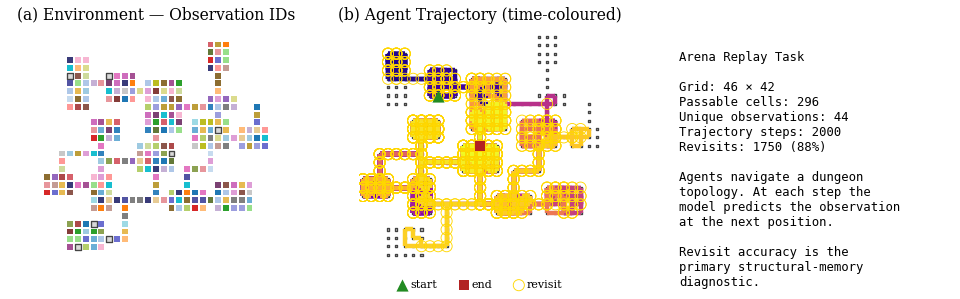

In [5]:
# Arena Task Overview (paradigm context; same dataset for both models)
overview_entry = tem_v1_report.figure_entry("arena_task_layout", preferred_format="png")
if overview_entry:
    abs_path = tem_v1_report.root / overview_entry.path
    display(Image(filename=str(abs_path)))
else:
    print("arena_task_layout not available.")

> Figure 1: Example episode in the Arena task. Panel (a) shows the dungeon topology, with free cells coloured by their unique observation ID. Panel (b) shows the agent's trajectory through the environment, coloured by time. Revisits are highlighted with yellow circles, indicating when the agent returns to a previously visited cell.


# Model Internals Inspected

The TEM architecture separates structural knowledge (MEC-like) from sensory
content (LEC-like) via a conjunctive hippocampal (HPC) binding. This report
inspects the following internal variables and pathways:

| System    | Scientific role                    | Report-facing name            |
| --------- | ---------------------------------- | ----------------------------- |
| LEC (`x`) | Sensory-content state              | LEC content-state activity    |
| MEC (`g`) | Structural state, path integration | MEC structural state          |
| HPC (`p`) | Structure-content binding          | HPC binding/place-like state  |
| Output    | Behavioral prediction (3 pathways) | Prediction argmax per pathway |
| Target    | Ground-truth observation sequence  | Target observation IDs        |


# Behavioral Performance

The primary metric for Arena-Struct is `accuracy_revisit` — accuracy on
steps where the agent returns to a previously visited cell. The secondary
metric is `accuracy_all` — overall next-observation prediction accuracy.

**Chance baseline:** Uniform random guessing over 45 observation classes
yields $1/45 \approx 0.022$.


## Model comparison

The code cell below prints the scalar metrics from their respective ReportRun
artifacts. It reports `accuracy_all`, `accuracy_revisit`, and summary metadata.


In [2]:
# Display metrics from both ReportRuns
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    if report is None:
        continue
    metrics = report.metrics()
    print(f"\n{label}:")
    for m in metrics:
        hb = " (higher is better)" if m.higher_is_better else ""
        print(f"  {m.metric:<30s} {m.value:<8.3f} {m.unit or '—':<10s} {hb}")

print()
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    if report is None:
        continue
    s = report.summary()
    print(
        f"{label}: {s['model_family']}, {s['metric_count']} metrics, "
        f"{s['figure_count']} figures"
    )


TEM v1:
  accuracy_all                   1.000    ratio       (higher is better)
  accuracy_revisit               1.000    ratio       (higher is better)

TEM v2:
  accuracy_all                   1.000    ratio       (higher is better)
  accuracy_revisit               1.000    ratio       (higher is better)

TEM v1: tem-v1, 2 metrics, 16 figures
TEM v2: tem-v2, 2 metrics, 16 figures


> **What to look for:** Both models should show near-ceiling accuracy on
> this 4-case diagnostic slice. Differences between v1 and v2 on this
> small slice should be checked against the evaluation configuration before
> being interpreted as a model-capability difference.


## Arena Prediction Overlays

Ground-truth observation sequence (`gt`) vs. three prediction pathways:

| Prediction pathway | Scientific role                                       |
| ------------------ | ----------------------------------------------------- |
| Inference          | Overall prediction, combining all sources of evidence |
| Retrieved          | Prediction based on retrieved memory traces           |
| Ancestral          | Prediction based on structural prior (MEC-like) alone |

Below is the first case's arena_prediction_overlay figure from each ReportRun.


TEM v1 — arena_prediction_overlay (case=arena_n1)


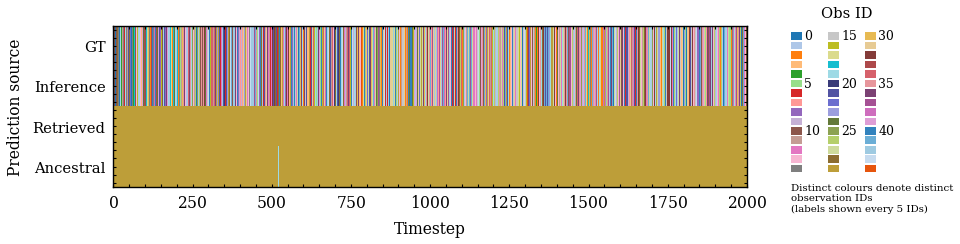

TEM v2 — arena_prediction_overlay (case=arena_n1)


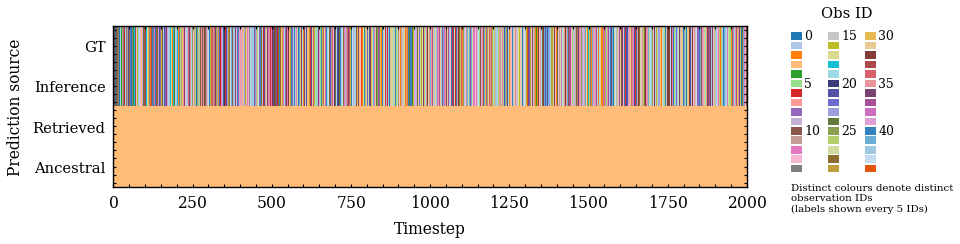

In [8]:
# --- MEC quantitative gridness metrics: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("arena_prediction_overlay", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: arena_prediction_overlay not available.")

> Figure 2: Prediction overlays for the first case in each ReportRun. Each sequence shows the predicted observation ID (colour) for each pathway (inference, retrieved, ancestral) compared to the ground-truth (GT) observation ID at each step. The pattern of mismatches across pathways can provide insight into the model's reliance on structural vs. content information for prediction.


# LEC / x Sensory-Content Diagnostics

The TEM implementation includes an explicit LEC stream that processes
observation embeddings before projection into HPC. In the
Tolman–Eichenbaum interpretation, this stream corresponds to the sensory/
content state $x$.

This section evaluates the LEC content stream in two ways. First, the
content-filtering diagnostic figure shows LEC content-state and
filtered-state per-unit activations across frequency bands, plus the
learned retention and input-mixing gate values annotated inside each
band label. Second, the content-vs-location contrast asks whether
LEC activity is organised more by sensory identity than by arena location,
and compares that organization against MEC/g and HPC/p.

Together, these figures test whether LEC acts as a content-state stream
rather than another spatial-map diagnostic.


## Content-state filtering

This is a **model-internal activation-flow diagnostic** for the sensory content stream — not a biological firing-rate raster. This section shows whether LEC units exhibit frequency-dependent activation structure and whether the filtering mechanism suppresses or enhances specific activation dimensions. It addresses whether the LEC stream shows content-related structure rather than undifferentiated activity.

**What to look for:** The content-state activations (panel a) should show structured patterns across frequency bands, with some units more active in certain bands. The filtered-state activations (panel b) should differ from the content-state, showing suppression or enhancement of specific dimensions. The filter effect (panel c) should highlight which activation dimensions are modulated by the frequency-dependent filtering, consistent with a content-filtering mechanism.


TEM v1 — lec_content_filtering (case=arena_n1)


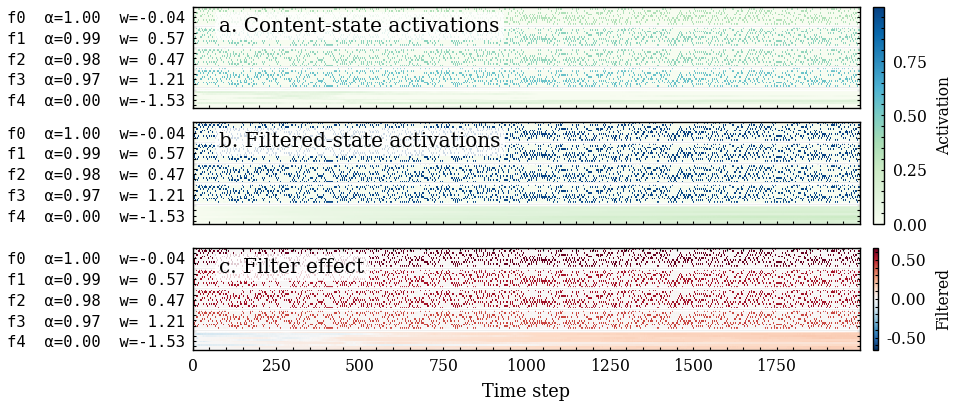

In [ ]:
# Figure 10a: lec_content_filtering
entry = tem_v1_report.figure_entry("lec_content_filtering", preferred_format="png")
if entry:
    abs_path = tem_v1_report.root / entry.path
    print(f"TEM v1 — {entry.figure_id} (case={entry.regime_id})")
    display(Image(filename=str(abs_path)))
else:
    print("lec_content_filtering not available in TEM v1 ReportRun.")

> Figure 3: Content-filtering diagnostic figure for the LEC stream. Panel (a) shows the content-state activations per unit, grouped by frequency band. Panel (b) shows the filtered-state activations in the same row order. Panel (c) shows the filter effect, highlighting which activation dimensions are suppressed or enhanced by the frequency-dependent filtering. The learned gate parameters ($\alpha_f$, $w_f$) are annotated in the band labels on the left margin.


## Content vs. location organisation across TEM streams

A TEM-style factorisation predicts a relative dissociation: LEC should
show stronger content organisation, MEC stronger location organisation,
and HPC may combine both. The figure reports the measured values.

Definitions:

- _content effect_ = mean similarity(same observation) − mean similarity(different observation)
- _location effect_ = mean similarity(same location) − mean similarity(different location)

**What to look for:** If LEC acts as a content stream, its states should
be more similar when the same observation is present, while MEC should
show stronger similarity for the same location, and HPC may combine both.


TEM v1 — lec_content_structure_rsa (case=arena_n1)


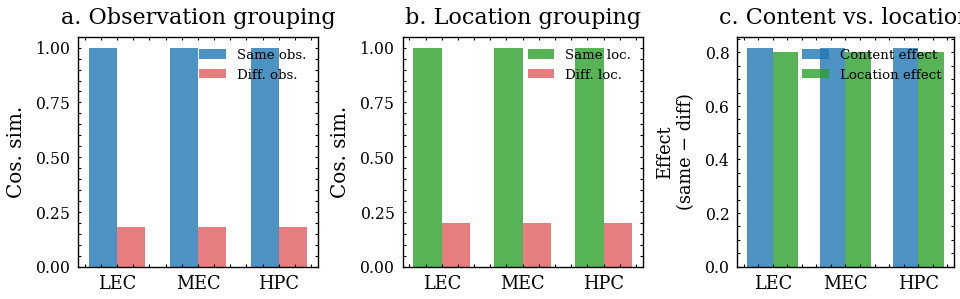

In [ ]:
# Figure 10b: lec_content_structure_rsa
entry = tem_v1_report.figure_entry("lec_content_structure_rsa", preferred_format="png")
if entry:
    abs_path = tem_v1_report.root / entry.path
    print(f"TEM v1 — {entry.figure_id} (case={entry.regime_id})")
    display(Image(filename=str(abs_path)))
else:
    print("lec_content_structure_rsa not available in TEM v1 ReportRun.")

> Figure 4: Content vs. location organization across TEM streams. Panel (a)
> shows the LEC similarity split by same/different observation, Panel (b) shows
> the MEC similarity split by same/different location, and Panel C plots the
> content effect vs location effect for all three streams (LEC, MEC, HPC).
> The relative magnitudes of these effects across streams can provide evidence
> for the functional roles of each stream in encoding content and structure.


**Author interpretation pending.**  
Interpret this figure in terms of:

- the visible pattern of content vs. location effects across LEC, MEC, and HPC,
- whether the dissociation supports or weakens the TEM factorisation prediction,
- the main limitation or failure mode.


**Section conclusion — LEC/x.**  
This section provides the diagnostics needed to assess whether LEC acts as a
content-stream rather than another spatial-map system. The content-filtering
figure can be used to inspect activation structure across frequency bands;
the content-vs-location RSA figure tests the predicted TEM factorisation.
Caveats: the `filtered` trace semantics require confirmation, gate parameters
are not yet populated, and no shuffle baselines are available.


# MEC / g Structural-Stream Diagnostics

This section evaluates whether the MEC-like structural state (`g`) encodes
environment topology with grid-like spatial periodicity.

| Field                | Status                                                                |
| -------------------- | --------------------------------------------------------------------- |
| ReportRun-backed     | ✅ Yes                                                                |
| Trace source         | `diagnostic/mec/location_mean`                                        |
| Evidence type        | Rate maps, autocorrelograms, gridness metrics, grid spacing estimates |
| Statistical baseline | ❌ Pending — no shuffle or occupancy-matched null baseline            |
| Caveat               | Gridness scores are descriptive only without a shuffle baseline.      |

### Figures

- `mec_grid_metrics`: Gridness scores and grid spacing by frequency band,
  with representative autocorrelograms for top-gridness cells.
- `mec_autocorr_mosaic`: Population autocorrelogram mosaic ordered by
  gridness score per frequency band.

> **Caveat:** Gridness is reported without shuffle baselines. Without an
> occupancy-matched null distribution, these scores are descriptive rather
> than statistically validated. They are consistent with grid-cell-like
> spatial periodicity but do not establish it.

Below are the `mec_grid_metrics` and `mec_autocorr_mosaic` figures from
each ReportRun.


**Figure: mec_grid_metrics.**  
Gridness scores and grid spacing by frequency band, with representative
autocorrelograms for top-gridness cells. Higher gridness scores are
consistent with spatial periodicity. The figure addresses whether MEC/g
states encode environment topology with grid-like structure.


TEM v1 — mec_grid_metrics (case=arena_n1)


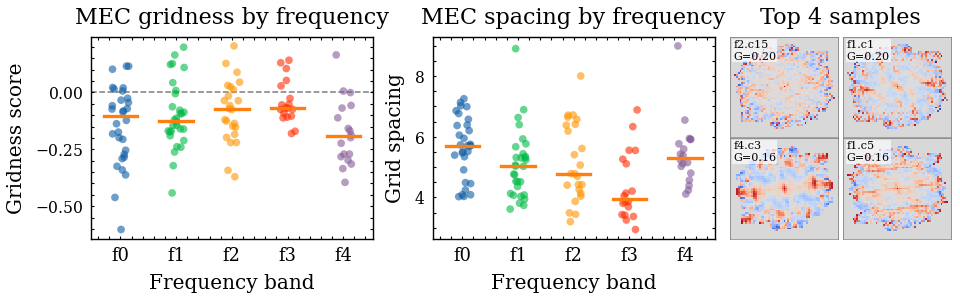


TEM v2 — mec_grid_metrics (case=arena_n1)


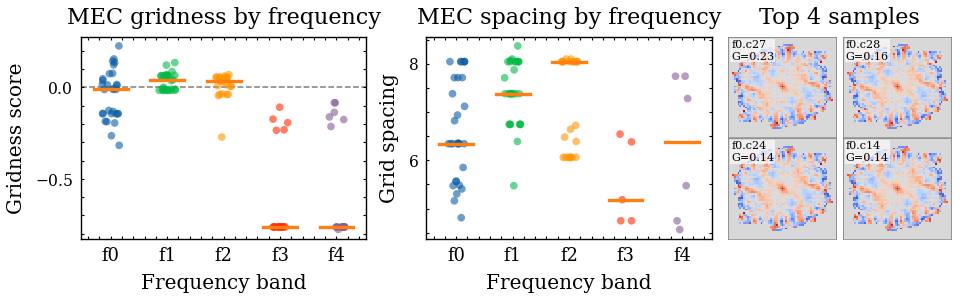

In [5]:
# --- MEC quantitative gridness metrics: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("mec_grid_metrics", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: mec_grid_metrics not available.")
    print()

**Author interpretation pending.**  
Interpret this figure in terms of:

- the visible pattern of gridness scores across frequency bands,
- whether top-gridness cells show periodic autocorrelograms,
- the main limitation or failure mode.


**Figure: mec_autocorr_mosaic.**  
Population autocorrelogram mosaic ordered by descending gridness score per
frequency band. This figure complements the quantitative gridness metrics by
showing the full population distribution of rate-map autocorrelation
structure.


TEM v1 — mec_autocorr_mosaic (case=arena_n1)


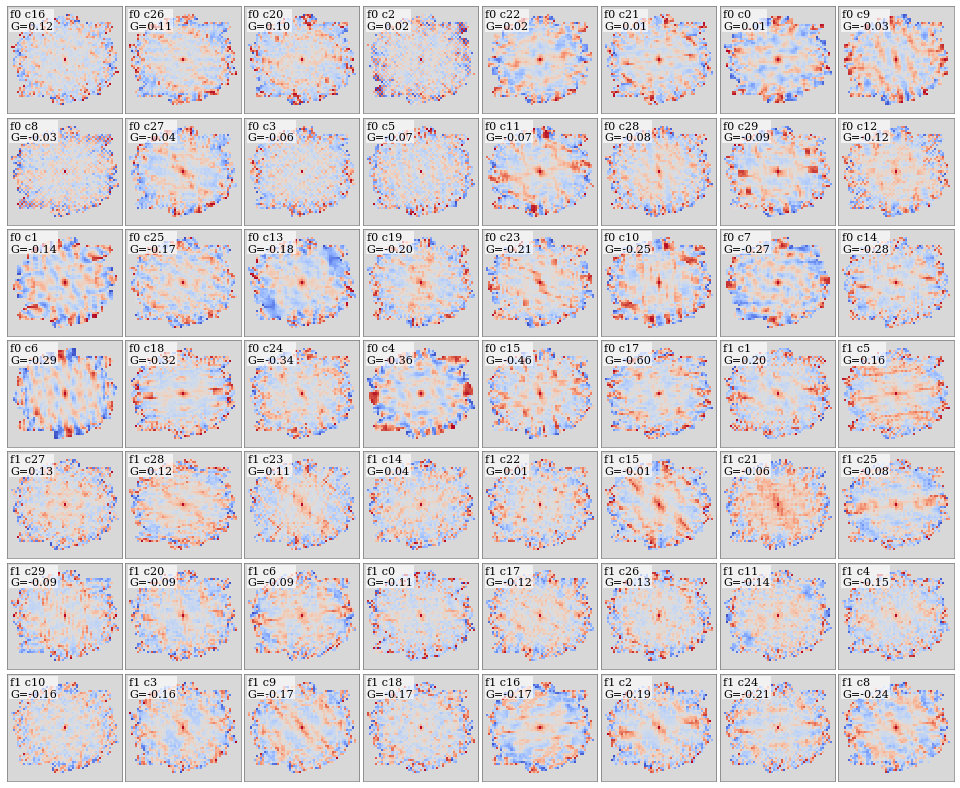


TEM v2 — mec_autocorr_mosaic (case=arena_n1)


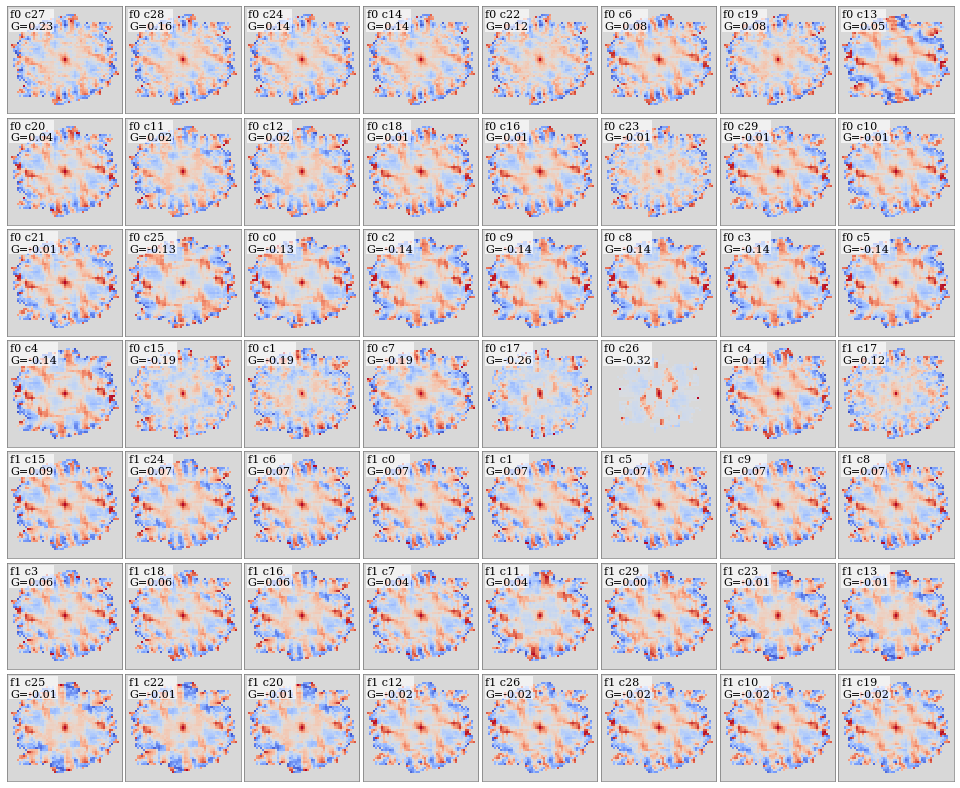

In [ ]:
# --- MEC autocorrelogram mosaic: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("mec_autocorr_mosaic", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: mec_autocorr_mosaic not available.")
    print()

**Author interpretation pending.**  
Interpret this figure in terms of:

- the visible range of autocorrelation structure across the population,
- whether high-gridness cells are distinct from the population mean,
- the main limitation or failure mode.


**Section conclusion — MEC/g.**  
This section provides the diagnostics needed to assess whether MEC/g states
exhibit grid-like spatial periodicity. Gridness scores can be compared
across frequency bands and between models; the presence of periodic
autocorrelograms can be inspected in the mosaic. The final conclusion should
be based on observed gridness values, the distribution across bands, and
comparison with a shuffle baseline (not yet available).


## 9. HPC / p Place and Binding Diagnostics

This section evaluates whether the hippocampal conjunctive state (`p`)
exhibits place-like spatial selectivity — localised firing to specific
positions in the environment.

| Field                       | Status                                                                                                                                                |
| --------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------- |
| ReportRun-backed            | ✅ Yes (place-like rate maps and spatial information)                                                                                                 |
| Trace source                | `diagnostic/hpc/location_mean`                                                                                                                        |
| Evidence type               | Spatial information scores, field-center scatter, rate-map examples, population mosaic                                                                |
| Conjunctive `g`-`x` binding | ⚠️ LEC traces are now available (§10), but full conjunctive `g`/`x`/`p` analysis still requires explicit cross-stream decoding or binding diagnostics |
| Statistical baseline        | ❌ Pending — no shuffle baseline for spatial information significance                                                                                 |
| Status                      | Rate maps and spatial information available; conjunctive binding requires further analysis                                                            |

### Figures

- `hpc_place_metrics`: Spatial information distribution (strip plot),
  field-center locations over the arena (scatter), and top-4 rate-map
  examples (2×2 mosaic).
- `hpc_rate_map_mosaic`: Flat wrapped population survey of rate maps
  ordered by descending spatial information.

> **Caveat:** Rate maps and spatial information scores can be used to
> assess spatial tuning. LEC content traces are now available (§10), but
> assessing whether HPC `p` binds separable structural and content signals
> requires cross-stream decoding or explicit conjunctivity diagnostics
> not yet implemented. Spatial information scores are reported without
> shuffle baselines.

Below are the `hpc_place_metrics` and `hpc_rate_map_mosaic` figures from
each ReportRun.


**Figure: hpc_place_metrics.**  
Spatial information distribution (strip plot), field-center locations over
the arena (scatter), and top-4 rate-map examples (2×2 mosaic). This figure
addresses whether the HPC/p conjunctive state exhibits place-like spatial
selectivity.


TEM v1 — hpc_place_metrics (case=arena_n1)


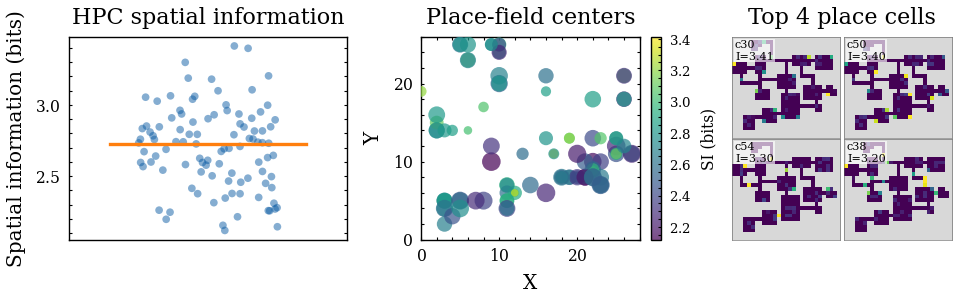


TEM v2 — hpc_place_metrics (case=arena_n1)


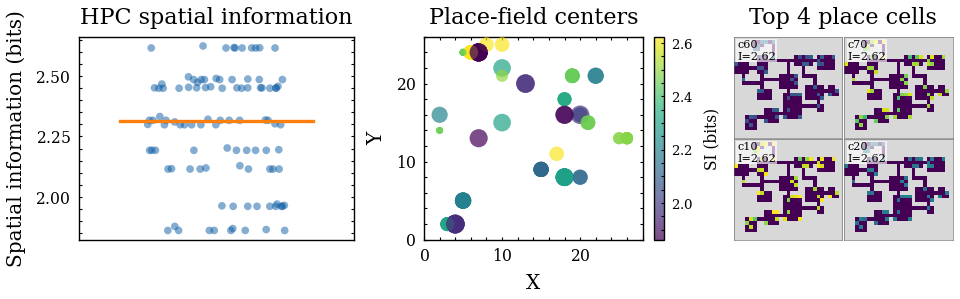

In [ ]:
# --- HPC place metrics: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("hpc_place_metrics", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: hpc_place_metrics not available.")
    print()

**Author interpretation pending.**  
Interpret this figure in terms of:

- the visible pattern of spatial information scores across units,
- whether field centers are distributed across the arena,
- the main limitation or failure mode.


**Figure: hpc_rate_map_mosaic.**  
Flat wrapped population survey of rate maps ordered by descending spatial
information. This figure complements the place metrics by showing the full
population distribution of spatial tuning.


TEM v1 — hpc_rate_map_mosaic (case=arena_n1)


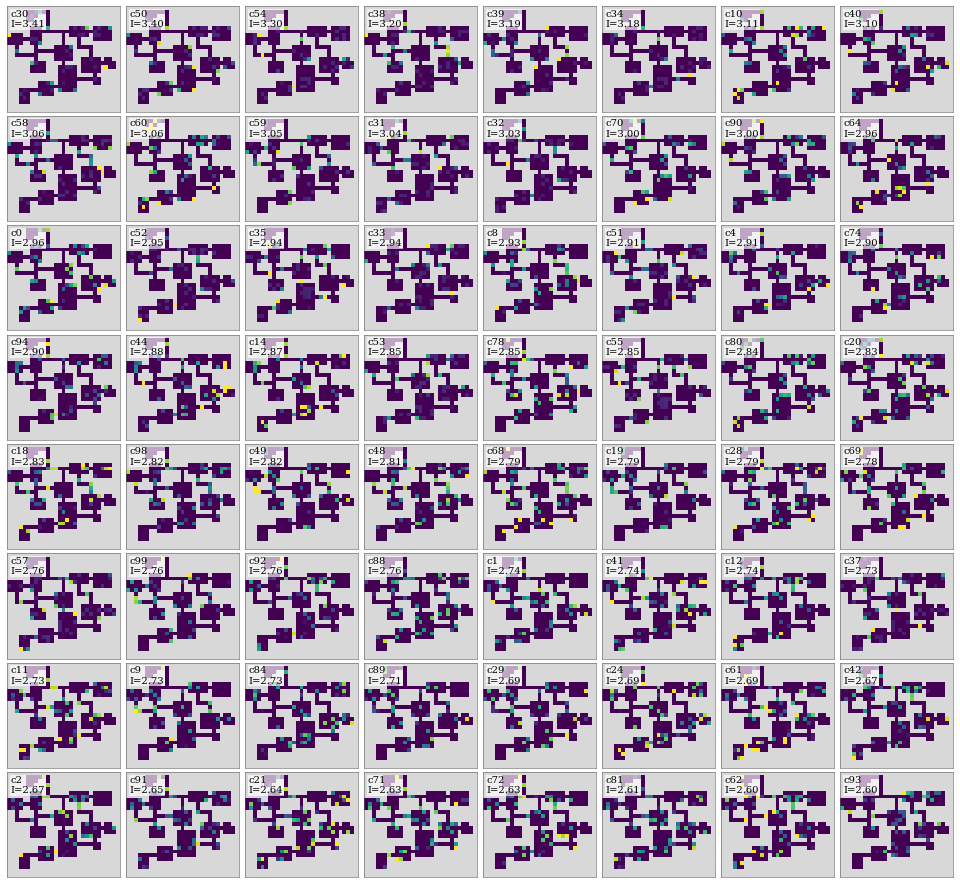


TEM v2 — hpc_rate_map_mosaic (case=arena_n1)


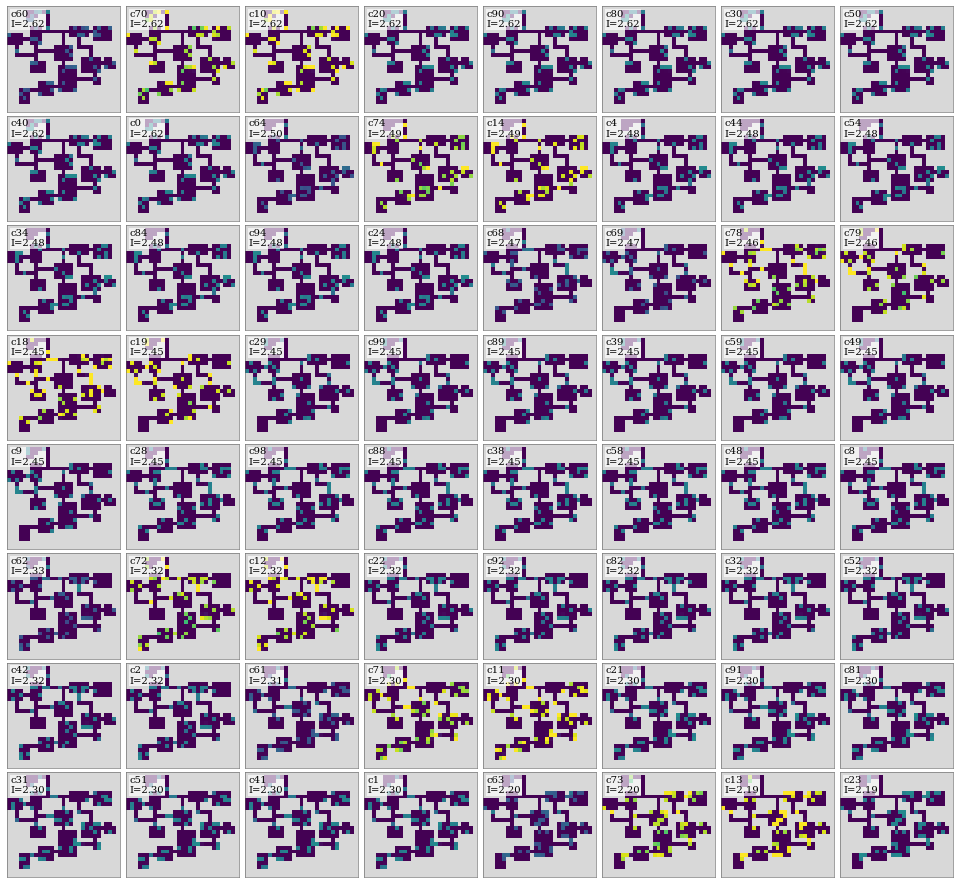

In [ ]:
# --- HPC rate-map mosaic: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("hpc_rate_map_mosaic", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: hpc_rate_map_mosaic not available.")
    print()

**Author interpretation pending.**  
Interpret this figure in terms of:

- the visible range of spatial tuning across the population,
- whether high-SI cells are distinct from the population mean,
- the main limitation or failure mode.


**Section conclusion — HPC/p.**  
This section provides the diagnostics needed to assess whether HPC/p states
exhibit place-like spatial selectivity. Spatial information scores, field-center
distributions, and rate-map examples can be inspected to evaluate spatial tuning.
Full conjunctive binding of separable structural and content signals requires
cross-stream decoding or explicit conjunctivity diagnostics not yet implemented.


## 11. Evidence Gaps and Next Diagnostic Steps

This section consolidates all claims that are **not yet** evaluated or
report-backed. Unlike the evidence sections above, these are not stubs —
they are explicit blocker statements grouped by missing claim.

| Missing claim                  | Why it matters                                                                                | Current blocker                                  | Next artifact needed                                |
| ------------------------------ | --------------------------------------------------------------------------------------------- | ------------------------------------------------ | --------------------------------------------------- |
| **Training convergence**       | Establishes checkpoint credibility; distinguishes learned structure from overfit memorisation | Training logs not ingested                       | Train/val loss metric artifact                      |
| **Retrieval pathway**          | Tests whether memory lookup (not only prediction) is correct and interpretable                | Retrieval-specific traces not exposed in report  | Retrieval trace fields + retrieval accuracy metrics |
| **Remapping / generalisation** | Tests whether structural codes are reusable across environments                               | Only single small eval slice (4 cases) available | Cross-environment eval set with sensory remapping   |
| **Gridness significance**      | Controls false-positive grid-cell claims                                                      | No shuffle baseline implemented                  | Shuffled occupancy / rate-map null distribution     |
| **Place-field significance**   | Controls false-positive place-like claims                                                     | No shuffle baseline for spatial information      | Shuffled spatial information null distribution      |
| **Ablations**                  | Tests causal role of MEC/LEC/HPC modules                                                      | No ablation report runs exist                    | MEC/LEC/HPC lesion configs + eval runs              |

### Priority Order for Next Implementation

1. **Add shuffle baselines** for gridness and spatial information metrics
2. **Expose retrieval traces** and add retrieval-specific metrics
3. **Build cross-environment eval set** to test remapping / generalisation
4. **Run ablation studies** (MEC lesion, LEC lesion, no-memory variant)
5. **Ingest training logs** into ReportRun format (train/val loss curves)


## 12. Evidence Summary

| Claim                                           | Variable / pathway                    | Current status                              | Evidence status                                                        |
| ----------------------------------------------- | ------------------------------------- | ------------------------------------------- | ---------------------------------------------------------------------- |
| Solves Arena prediction task                    | Output predictions                    | ReportRun-backed (§6)                       | ✅ Available (n=4 diagnostic slice)                                    |
| Forms structural map                            | MEC / `g`                             | ReportRun-backed (§8)                       | ✅ Available — gridness metrics computed, descriptive                  |
| Encodes sensory content separate from structure | LEC / `x`                             | ReportRun-backed (§10)                      | ✅ Available — content-filtering and content-structure RSA diagnostics |
| Binds content to structure (conjunctive)        | HPC / `p`                             | Partially available (§9)                    | ⚠️ Place-like maps available; conjunctive binding not yet evaluated    |
| Retrieves stored structure-content associations | Memory / retrieval path               | Not yet main-report-ready (§11)             | ❌ Not yet evaluated — trace gap                                       |
| Generalises / remaps across environments        | Cross-env behaviour + representations | No cross-env eval set (§11)                 | ❌ Not yet evaluated                                                   |
| Gridness above shuffle                          | MEC / `g`                             | Gridness scores available, no baseline (§8) | ⚠️ Descriptive only — no shuffle baseline                              |
| Place-field above shuffle                       | HPC / `p`                             | SI scores available, no baseline (§9)       | ⚠️ Descriptive only — no shuffle baseline                              |
| Ablations confirm causal role                   | MEC / LEC / HPC                       | No ablation runs exist (§11)                | ❌ Not yet evaluated                                                   |

### Bottom Line

> Current evidence covers behavioral prediction on a bounded 4-case
> diagnostic slice, plus MEC/g structural diagnostics, LEC/x
> content-selectivity diagnostics, and HPC/p place-like diagnostics. The
> following are not yet addressed: (1) training convergence evidence,
> (2) explicit `g`/`x`/`p` disentanglement via remapping, (3) memory-retrieval
> diagnostics, (4) cross-environment generalisation, (5) shuffle baselines
> for gridness and spatial information, and (6) ablations.


## 13. Reproducibility

### Artifact Paths

| Artifact                    | Path                                                    |
| --------------------------- | ------------------------------------------------------- |
| TEM v1 ReportRun            | `artifacts/reports/tem_v1/arena_n1`                     |
| TEM v2 ReportRun            | `artifacts/reports/tem_v2/arena_n1`                     |
| TEM v1 eval artifacts       | `artifacts/evaluation/tem_v1/arena_n1`                  |
| TEM v2 eval artifacts       | `artifacts/evaluation/tem_v2/arena_n1`                  |
| TEM v1 checkpoint           | `checkpoints/tem-v1/eval-weights-only.pt` (step 10,000) |
| TEM v2 checkpoint           | `checkpoints/tem-v2/eval-weights-only.pt` (step 10,000) |
| TEM v1 model config         | `config/models/tem-v1-base.toml`                        |
| TEM v2 model config         | `config/models/tem-v2-base.toml`                        |
| TEM v1 report spec          | `config/reporting/tem_v1_arena_n4.toml`                 |
| TEM v2 report spec          | `config/reporting/tem_v2_arena_n4.toml`                 |
| Arena-Struct benchmark spec | `spec/spec-benchmark-suite.md` §6.1                     |

### Commands to Reproduce (current eval with LEC traces, n=1)

```bash
# Generate evaluation artifacts with all diagnostic traces (n=1)
python scripts/evaluation/run_eval.py \
    --model-family tem-v1 \
    --checkpoint checkpoints/tem-v1/eval-weights-only.pt \
    --config config/evaluation/tem-v1-arena.toml \
    --task arena \
    --provider-ref ehc_sn.tasks.arena.providers.ArenaReplayProvider \
    --provider-settings '{"dataset_path": "data/processed/arena/default/v1", "split": "test", "n_cases": 1}' \
    --regime-id arena_n1 --regime-kind diagnostic \
    --output artifacts/evaluation/tem_v1/arena_n1 --device cpu \
    --trace-keys '["diagnostic/mec/location_mean","diagnostic/hpc/location_mean","diagnostic/lec/cells","diagnostic/lec/filtered","world_step/observation","pred/observation_id/inference","pred/observation_id/retrieved","pred/observation_id/ancestral"]'

# Generate ReportRun from eval artifacts
python scripts/reporting/run_report.py \
    --config config/reporting/tem_v1_arena_n1.toml
```

### Known Reproducibility Gaps

| Gap                                 | Impact                                                                       |
| ----------------------------------- | ---------------------------------------------------------------------------- |
| Git commit SHA not recorded         | Cannot pin the exact code version                                            |
| Checkpoint SHA256 not recorded      | Cannot verify checkpoint integrity                                           |
| Random seed not recorded            | Cannot reproduce stochastic elements                                         |
| `diagnostic/lec/filtered` semantics | Not yet confirmed — may be frequency decomposition, not temporal persistence |
| LEC-to-HPC binding pathway          | Cross-stream decoding diagnostics not yet implemented                        |
| EHC v1 / EHC v2 checkpoints         | Not yet trained; structural-memory comparison incomplete                     |
